In [1]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [2]:
!pip3 install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 13.1 MB/s eta 0:00:00


In [1]:
import os
from os import listdir
import random
import gc
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
import sys
from glob import glob
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

## Load in Data

In [2]:
# import csv
path = "C:\\Users\\ojlass\\Desktop\\Honda Project\\Gabby code\\merged\\interpolated_alt_seg_insole_sensor_df.csv"

interpolated_insole_df = pd.read_csv(path)

# # only keep participants 1 - 5
# interpolated_insole_df = interpolated_insole_df[interpolated_insole_df['participant_id'] <= 5]

In [3]:
interpolated_insole_df['gait_cycle_id'] = interpolated_insole_df['participant_id'].astype(str) + '_' + interpolated_insole_df['task'].astype(str) + '_' + interpolated_insole_df['segment_count'].astype(str)

In [4]:
interpolated_insole_df[['Left_norm', 'Right_norm', 'Left_norm_cumulative', 'Right_norm_cumulative']] = (interpolated_insole_df[['Left_norm', 'Right_norm', 'Left_norm_cumulative', 'Right_norm_cumulative']] * 1000).astype(int)  # or np.int16 if values allow
interpolated_insole_df[['time','participant_id', 'segment_count']] = interpolated_insole_df[['time', 'participant_id', 'segment_count']].astype(int)  # or smaller if possible
interpolated_insole_df[['task', 'walk_mode']] = interpolated_insole_df[['task', 'walk_mode']].astype(int)  # Assuming these are categorical with limited values

In [5]:
le = LabelEncoder()
interpolated_insole_df['task'] = le.fit_transform(interpolated_insole_df['task'])
interpolated_insole_df['walk_mode'] = le.fit_transform(interpolated_insole_df['walk_mode'])

In [6]:
interpolated_insole_df.sort_values(by=['participant_id', 'task', 'segment_count', 'time', 'sensor_location'], inplace=True)

In [7]:
# Map groups and locations (same as before)
group_mapping = {
    'front': ['Hallux', 'Toes', 'Met1'],
    'middle': ['Met3', 'Met5', 'Arch'],
    'back': ['Heel_L', 'Heel_R', 'Arch']
}

location_mapping = {}
for group, sensors in group_mapping.items():
    location_mapping.update({sensor: f"Location_{i+1}" for i, sensor in enumerate(sensors)})

interpolated_insole_df['group'] = interpolated_insole_df['sensor_location'].map(
    lambda x: 'front' if x in group_mapping['front'] else
              'middle' if x in group_mapping['middle'] else
              'back' if x in group_mapping['back'] else None
)

In [8]:
# take every row that has arch for a sensor location and duplicate it but now with the group being "back"
arch_rows = interpolated_insole_df[interpolated_insole_df['sensor_location'] == 'Arch']
back_rows = arch_rows.copy()
back_rows['group'] = 'back'
interpolated_insole_df = pd.concat([interpolated_insole_df, back_rows])

In [9]:
# Group and aggregate data
grouped_df = (
    interpolated_insole_df
    .groupby(['group', 'gait_cycle_id', 'time', 'group'])[['Right_norm', 'Left_norm']]
    .sum()  # Aggregate (mean) the norm values
    .unstack(level=-1)  # Unstack the location to columns
)

In [10]:
# Reset index of grouped_df to flatten it for easy merging
grouped_df_reset = grouped_df.reset_index()
# Flatten multi-level columns into a single level
grouped_df_reset.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else col for col in grouped_df_reset.columns]
# rename gait_cycle_id_ in grouped_df_reset
grouped_df_reset = grouped_df_reset.rename({'gait_cycle_id_': 'gait_cycle_id', 'time_': 'time', 'group_': 'group'}, axis=1)


In [11]:
grouped_df_reset["Right_norm_grouped"] = grouped_df_reset["Right_norm_back"].fillna(0) + grouped_df_reset["Right_norm_middle"].fillna(0) + grouped_df_reset["Right_norm_front"].fillna(0).astype(int)
grouped_df_reset["Left_norm_grouped"] = grouped_df_reset["Left_norm_back"].fillna(0) + grouped_df_reset["Left_norm_middle"].fillna(0) + grouped_df_reset["Left_norm_front"].fillna(0).astype(int)


In [12]:
del grouped_df
del back_rows
del arch_rows

In [13]:
# drop right_norm_back, right_norm_middle...
grouped_df_reset = grouped_df_reset.drop(columns=['Right_norm_back', 'Right_norm_middle', 'Right_norm_front', 'Left_norm_back', 'Left_norm_middle', 'Left_norm_front'])

In [14]:
grouped_df_reset.sort_values(by=['gait_cycle_id', 'time', 'group'], inplace=True)
interpolated_insole_df.sort_values(by=['gait_cycle_id', 'time', 'group'], inplace=True)
insole_dfs = pd.merge(interpolated_insole_df, grouped_df_reset, on=['gait_cycle_id', 'time', 'group'], how='left')

In [15]:
# Filter sensor locations more efficiently
valid_sensors = {'Hallux', 'Heel_L', 'Heel_R', 'Met5'}
insole_dfs = insole_dfs[insole_dfs['sensor_location'].isin(valid_sensors)]

In [16]:
insole_dfs = insole_dfs.reset_index(drop=True)

In [17]:
df_long = insole_dfs.melt(
    id_vars=["time", "participant_id", "task", "segment_count", "walk_mode", "sensor_location", "gait_cycle_id", "group"],
    value_vars=["Left_norm", "Right_norm"],
    var_name="foot_position",
    value_name="norm"
)

df_long["foot_position"] = df_long["foot_position"].apply(lambda x: "left" if "Left" in x else "right")


In [18]:
df_long_cumulative = insole_dfs.melt(
    id_vars=["time", "participant_id", "task", "segment_count", "walk_mode", "sensor_location", "gait_cycle_id", "group"],
    value_vars=["Left_norm_cumulative", "Right_norm_cumulative"],
    var_name="foot_position",
    value_name="norm_cumulative"
)

In [19]:
df_long_grouped = insole_dfs.melt(
    id_vars=["time", "participant_id", "task", "segment_count", "walk_mode", "sensor_location", "gait_cycle_id", "group"],
    value_vars=["Left_norm_grouped", "Right_norm_grouped"],
    var_name="foot_position",
    value_name="norm_grouped"
)


In [20]:
# Ensure foot_position names match across all melted DataFrames
df_long_cumulative["foot_position"] = df_long_cumulative["foot_position"].apply(lambda x: "left" if "Left" in x else "right")
df_long_grouped["foot_position"] = df_long_grouped["foot_position"].apply(lambda x: "left" if "Left" in x else "right")

# Merge the transformed DataFrames
df_final = df_long.merge(df_long_cumulative, on=["time", "participant_id", "task", "segment_count", "walk_mode", "sensor_location", "gait_cycle_id", "group", "foot_position"])
df_final = df_final.merge(df_long_grouped, on=["time", "participant_id", "task", "segment_count", "walk_mode", "sensor_location", "gait_cycle_id", "group", "foot_position"])

# Final columns order
df_final = df_final[[
    "time", "participant_id", "task", "norm", "norm_cumulative", "segment_count", "walk_mode",
    "sensor_location", "gait_cycle_id", "group", "norm_grouped", "foot_position"
]]

In [21]:
df_final = df_final.sort_values(by=['participant_id', 'task', 'segment_count', 'time', 'foot_position', 'group'])

In [22]:
# sort by participant id, task, and gait cycle
df_transformed = df_final.copy()

In [23]:
# rename column
df_transformed.rename(columns={'sensor_location': 'insole_location', 'participant_id_x': 'participant_id', 'segment_count_x': 'segment_count', 'task_x': 'task'}, inplace=True)

In [24]:
filtered_df = df_transformed[
    ~(
        ((df_transformed['foot_position'] == 'right') & (df_transformed['insole_location'] == 'Heel_L')) |
        ((df_transformed['foot_position'] == 'left') & (df_transformed['insole_location'] == 'Heel_R'))
    )
]

In [25]:
info = filtered_df[['time', 'participant_id', 'task', 'segment_count', 'gait_cycle_id', 'foot_position', 'walk_mode']]


In [26]:
# group by left and right
# maintain walk_mode and gait_cycle_id variables in side groupings
side_groupings = filtered_df.groupby(by=['participant_id', 'task', 'segment_count', 'time', 'foot_position'])[['norm', 'norm_grouped', 'norm_cumulative']].apply(lambda x: x.values.tolist())


In [27]:
side_groupings = side_groupings.reset_index()

In [28]:
side_groupings_list = list(side_groupings[0])
adjusted_list = []

for i in range(len(side_groupings_list)):  # Loop through all elements
    try:
        norm_group_back = side_groupings_list[i][0][1]
        norm_group_front = side_groupings_list[i][1][1]
        norm_group_mid = side_groupings_list[i][2][1]
        norm_toe = side_groupings_list[i][1][0]
        norm_heel = side_groupings_list[i][0][0]
        cumulative = side_groupings_list[i][0][2]

        input_list = [norm_group_front, norm_group_mid, norm_group_back, norm_toe, norm_heel, cumulative]
        adjusted_list.append(input_list)
    except IndexError:
        print(f"Skipping index {i} due to missing data: {side_groupings_list[i]}")


In [29]:
adjusted_list[0]

[3.0, 3.0, 830.0, 0.0, 457.0, 838.0]

In [30]:
# Convert inputs_combo to a NumPy array
inputs_combo_array = np.array(adjusted_list)

# Assign values correctly
side_groupings['acceleration_x'] = inputs_combo_array[:, 0] # norm group front
side_groupings['acceleration_y'] = inputs_combo_array[:, 1] # norm group mid
side_groupings['acceleration_z'] = inputs_combo_array[:, 2] # norm group back
side_groupings['angularVelocity_x'] = inputs_combo_array[:, 3] # norm toe
side_groupings['angularVelocity_y'] = inputs_combo_array[:, 4] # norm heel
side_groupings['angularVelocity_z'] = inputs_combo_array[:, 5] # norm cumulative

In [31]:
del adjusted_list
# del filtered_df
del side_groupings_list
del insole_dfs
del filtered_df

In [32]:
side_groupings = side_groupings.drop(columns=[0])

In [33]:
side_groupings = side_groupings.rename(columns={'foot_position': 'sensor_location'})

In [34]:
side_groupings = pd.merge(side_groupings, info, on=['time', 'participant_id', 'task', 'segment_count'])

In [35]:
side_groupings.head()

,participant_id,task,segment_count,time,sensor_location,acceleration_x,acceleration_y,acceleration_z,angularVelocity_x,angularVelocity_y,angularVelocity_z,gait_cycle_id,foot_position,walk_mode
0,1,0,1,0,left,3.0,3.0,830.0,0.0,457.0,838.0,1.0_0.0_1.0,left,4
1,1,0,1,0,left,3.0,3.0,830.0,0.0,457.0,838.0,1.0_0.0_1.0,left,4
2,1,0,1,0,left,3.0,3.0,830.0,0.0,457.0,838.0,1.0_0.0_1.0,left,4
3,1,0,1,0,left,3.0,3.0,830.0,0.0,457.0,838.0,1.0_0.0_1.0,right,4
4,1,0,1,0,left,3.0,3.0,830.0,0.0,457.0,838.0,1.0_0.0_1.0,right,4


In [36]:
gc.collect()

0

In [37]:
path_imu = "C:\\Users\\ojlass\\Desktop\\Honda Project\\Gabby code\\merged\\interpolated_alt_seg_imu_sensor_df.csv"

interpolated_imu_df = pd.read_csv(path_imu)

# # only keep participants 1 - 5
# interpolated_imu_df = interpolated_imu_df[interpolated_imu_df['participant_id'] <= 5]


lower_body_imu_sensor_locations = ['Pelvis', 'RightUpperLeg', 'LeftUpperLeg', 'RightLowerLeg', 'LeftLowerLeg', 'RightFoot', 'LeftFoot']

# retain the sensors that are in the luo_imu_sensor_locations list
interpolated_imu_df = interpolated_imu_df[interpolated_imu_df['sensor_location'].isin(lower_body_imu_sensor_locations)]

interpolated_imu_df['gait_cycle_id'] = interpolated_imu_df['participant_id'].astype(str) + '_' + interpolated_imu_df['task'].astype(str) + '_' + interpolated_imu_df['segment_count'].astype(str)

# normalize each measurement column
interpolated_imu_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']] = (interpolated_imu_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']].apply(lambda x: (x - x.mean()) / x.std()) * 1000).astype(int)
interpolated_imu_df[['time', 'segment_count', 'participant_id', 'task', 'walk_mode']] = interpolated_imu_df[['time', 'segment_count', 'participant_id', 'task', 'walk_mode']].astype(int)

le = LabelEncoder()

interpolated_imu_df['task'] = le.fit_transform(interpolated_imu_df['task'])
interpolated_imu_df['walk_mode'] = le.fit_transform(interpolated_imu_df['walk_mode'])

In [38]:
import random

number_list = list(interpolated_imu_df['participant_id'].unique())
# Choose 3 numbers without replacement
test_three_numbers = random.sample(number_list, 2)
print(test_three_numbers)
train_list = [x for x in number_list if x not in test_three_numbers]

val_three_numbers = random.sample(train_list, 2)
print(val_three_numbers)

train_list = [x for x in train_list if x not in val_three_numbers]
print(train_list)

[4, 22]
[2, 7]
[1, 3, 5, 8, 10, 12, 13, 14, 15, 16, 17, 18, 19, 23, 24, 25]


In [39]:
train_imu = interpolated_imu_df.loc[interpolated_imu_df['participant_id'].isin(train_list)]
val_imu = interpolated_imu_df.loc[interpolated_imu_df['participant_id'].isin(val_three_numbers)]
test_imu = interpolated_imu_df.loc[interpolated_imu_df['participant_id'].isin(test_three_numbers)]

In [40]:
train_insole = side_groupings.loc[side_groupings['participant_id'].isin(train_list)]
val_insole = side_groupings.loc[side_groupings['participant_id'].isin(val_three_numbers)]
test_insole = side_groupings.loc[side_groupings['participant_id'].isin(test_three_numbers)]

In [41]:
# concat the train with train, val with val, ...
train = pd.concat([train_imu, train_insole])
val = pd.concat([val_imu, val_insole])
test = pd.concat([test_imu, test_insole])

In [42]:
train.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)
val.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)
test.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [140]:
# del interpolated_imu_df
# del df_transformed
# del side_groupings

In [43]:
train = train.drop_duplicates(subset=['participant_id', 'task', 'time', 'segment_count', 'sensor_location', 'walk_mode'], keep='first')
val = val.drop_duplicates(subset=['participant_id', 'task', 'time', 'segment_count', 'sensor_location', 'walk_mode'], keep='first')
test = test.drop_duplicates(subset=['participant_id', 'task', 'time', 'segment_count', 'sensor_location', 'walk_mode'], keep='first')

In [44]:
# Optional: Reset index after merging
train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)


In [45]:
train_gc = train.drop_duplicates(subset=['gait_cycle_id'], keep='first')

In [46]:
# count how many unique gait cycle ids are in each walk mode
train_gc[['walk_mode']].value_counts()

walk_mode
4            39683
0            13267
1             9911
3             5562
2             3163
Name: count, dtype: int64

In [47]:
# balance the classes to the median value
min_samples = int(train_gc['walk_mode'].value_counts().min())

In [48]:
# Downsample to balance classes
balanced_gait_cycles_df = (
    train_gc.groupby('walk_mode')
    .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))
    .reset_index(drop=True)
)


C:\Users\ojlass\AppData\Local\Temp\ipykernel_17640\1323091765.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))


In [49]:
balanced_gait_cycles_df['sensor_location'].unique()

array(['LeftFoot'], dtype=object)

In [50]:
print(balanced_gait_cycles_df['walk_mode'].value_counts())

walk_mode
0    3163
1    3163
2    3163
3    3163
4    3163
Name: count, dtype: int64


In [51]:
filtered_interpolated_final_df = pd.merge(
    train,
    balanced_gait_cycles_df[['gait_cycle_id']],
    on='gait_cycle_id',
    how='inner'
)

In [52]:
train = filtered_interpolated_final_df.copy()

In [53]:
train.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [54]:
train['sensor_location'].unique()

array(['LeftFoot', 'LeftLowerLeg', 'LeftUpperLeg', 'Pelvis', 'RightFoot',
       'RightLowerLeg', 'RightUpperLeg', 'left', 'right'], dtype=object)

In [55]:
le = LabelEncoder()

train['gait_cycle_id'] = le.fit_transform(train['gait_cycle_id'])
train['sensor_location'] = le.fit_transform(train['sensor_location'])
train['task'] = le.fit_transform(train['task'])
train['walk_mode'] = le.fit_transform(train['walk_mode'])

val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
val['sensor_location'] = le.fit_transform(val['sensor_location'])
val['task'] = le.fit_transform(val['task'])
val['walk_mode'] = le.fit_transform(val['walk_mode'])

test['gait_cycle_id'] = le.fit_transform(test['gait_cycle_id'])
test['sensor_location'] = le.fit_transform(test['sensor_location'])
test['task'] = le.fit_transform(test['task'])
test['walk_mode'] = le.fit_transform(test['walk_mode'])

In [56]:
train['walk_mode'].value_counts()

walk_mode
4    2277360
2    2277360
3    2277360
0    2277360
1    2277360
Name: count, dtype: int64

In [57]:
val['sensor_location'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [58]:
train = train.sort_values(by=['time', 'participant_id', 'sensor_location'])

In [59]:
del filtered_interpolated_final_df
del train_gc
del balanced_gait_cycles_df
del train_insole
del train_imu

In [60]:
def preprocess_data(df):
    # Initialize a list to hold data for each sensor location
    sensor_data_dict = {sensor: [] for sensor in df['sensor_location'].unique()}
    all_labels_y = []  # For storing labels for each gait cycle

    for gait_cycle_id, group_data in df.groupby('gait_cycle_id'):
        # Sort by time to ensure consistent order
        group_data = group_data.sort_values(by='time')

        # Process each sensor location
        for sensor_location, sensor_group in group_data.groupby('sensor_location'):
            # Extract the six IMU features
            sensor_array = sensor_group[['acceleration_x', 'acceleration_y', 'acceleration_z',
                                         'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']].values

            # Pad or truncate to ensure length of 80
            if len(sensor_array) < 80:
                padding = np.zeros((80 - len(sensor_array), 6))  # Pad with 6 zeros
                sensor_array = np.vstack([sensor_array, padding])
            elif len(sensor_array) > 80:
                sensor_array = sensor_array[:80]

            # Append the processed sensor data for the current sensor location
            sensor_data_dict[sensor_location].append(sensor_array)

        # Extract walk mode labels for the gait cycle
        walk_mode_data = group_data['walk_mode'].values[:80]
        if len(walk_mode_data) < 80:
            walk_mode_data = np.pad(walk_mode_data, (0, 80 - len(walk_mode_data)), constant_values=-1)  # Use -1 for padding
        all_labels_y.append(walk_mode_data)

    # Convert sensor data for each sensor location into a NumPy array with shape [x, 80, 6]
    all_sensor_data = [np.array(sensor_data_dict[sensor]) for sensor in sorted(sensor_data_dict.keys())]

    print(len(all_sensor_data))
    print(all_sensor_data[0].shape)

    # Convert labels to a NumPy array with shape [x, 80]
    all_labels_x = np.array(all_sensor_data)
    all_labels_y = np.array(all_labels_y)  # Shape: [x, 80]

    return all_sensor_data, all_labels_y


In [61]:
train_all_data_x, train_all_labels_y = preprocess_data(train)

9
(15815, 80, 6)


In [62]:
val_all_data_x, val_all_labels_y = preprocess_data(val)

9
(8180, 80, 6)


In [63]:
test_all_data_x, test_all_labels_y = preprocess_data(test)

9
(7987, 80, 6)


In [64]:
train_all_data_x_np = np.array(train_all_data_x)
val_all_data_x_np = np.array(val_all_data_x)
test_all_data_x_np = np.array(test_all_data_x)

In [65]:
train_all_labels_y = np.swapaxes(train_all_labels_y, 0, 1)
train_all_labels_y = train_all_labels_y[0]

val_all_labels_y = np.swapaxes(val_all_labels_y, 0, 1)
val_all_labels_y = val_all_labels_y[0]

test_all_labels_y = np.swapaxes(test_all_labels_y, 0, 1)
test_all_labels_y = test_all_labels_y[0]

In [66]:
from keras.utils import to_categorical

# Assuming the labels are already numeric
train_all_labels_y = to_categorical(train_all_labels_y)
val_all_labels_y = to_categorical(val_all_labels_y)
test_all_labels_y = to_categorical(test_all_labels_y)

In [67]:
train_all_labels_y.shape, train_all_labels_y[0]

((15815, 5), array([0., 0., 1., 0., 0.]))

In [68]:
train_all_data_x_np.shape, train_all_labels_y.shape, val_all_data_x_np.shape, val_all_labels_y.shape, test_all_data_x_np.shape, test_all_labels_y.shape

((9, 15815, 80, 6),
 (15815, 5),
 (9, 8180, 80, 6),
 (8180, 5),
 (9, 7987, 80, 6),
 (7987, 5))

In [69]:
train_X = train_all_data_x_np
train_Y = train_all_labels_y

val_X = val_all_data_x_np
val_Y = val_all_labels_y

test_X = test_all_data_x_np
test_Y = test_all_labels_y

In [70]:
n_obs, n_timesteps, n_features, n_classes = train_X.shape[1], train_X.shape[2], train_X.shape[3], train_Y.shape[1]

In [71]:
n_obs, n_timesteps, n_features, n_classes

(15815, 80, 6, 5)

In [72]:
train_X.shape

(9, 15815, 80, 6)

In [73]:
train_X_list = [train_all_data_x_np[i] for i in range(train_all_data_x_np.shape[0])]
train_Y_list = [train_all_labels_y for i in range(train_all_data_x_np.shape[0])]

val_X_list = [val_all_data_x_np[i] for i in range(val_all_data_x_np.shape[0])]
val_Y_list = [val_all_labels_y for i in range(val_all_data_x_np.shape[0])]

test_X_list = [test_all_data_x_np[i] for i in range(test_all_data_x_np.shape[0])]

test_Y_list = [test_all_labels_y for i in range(test_all_data_x_np.shape[0])]

# Print the shape of each item in the list to verify
for idx, sensor_data in enumerate(train_X_list):
    print(f"Sensor {idx+1} shape: {sensor_data.shape}")
    print(f"Label {idx+1} shape: {train_Y_list[idx].shape}")
    print()

Sensor 1 shape: (15815, 80, 6)
Label 1 shape: (15815, 5)

Sensor 2 shape: (15815, 80, 6)
Label 2 shape: (15815, 5)

Sensor 3 shape: (15815, 80, 6)
Label 3 shape: (15815, 5)

Sensor 4 shape: (15815, 80, 6)
Label 4 shape: (15815, 5)

Sensor 5 shape: (15815, 80, 6)
Label 5 shape: (15815, 5)

Sensor 6 shape: (15815, 80, 6)
Label 6 shape: (15815, 5)

Sensor 7 shape: (15815, 80, 6)
Label 7 shape: (15815, 5)

Sensor 8 shape: (15815, 80, 6)
Label 8 shape: (15815, 5)

Sensor 9 shape: (15815, 80, 6)
Label 9 shape: (15815, 5)



## hyperparameter tuning

In [74]:
!pip3 install keras-tuner -q

In [75]:
subset_size = int(0.5 * len(train_X_list[0]))  # Take 50% of the data
train_X_subset = [x[:subset_size] for x in train_X_list]
train_Y_subset = [y[:subset_size] for y in train_Y_list]
val_X_subset = [x[:subset_size] for x in val_X_list]
val_Y_subset = [y[:subset_size] for y in val_Y_list]

In [182]:
# # Clears the session for TensorFlow
# tf.keras.backend.clear_session()

In [76]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, BatchNormalization, \
    Bidirectional, LSTM, Dense, Attention, Concatenate, Flatten
from tensorflow.keras.models import Model

# Define input shape
input_shape = (n_timesteps, n_features)
num_sensors = len(train_X_list)  # Fixed number of sensor inputs
n_classes = 5

# Function to build the model with hyperparameter tuning
def build_model(hp):
    inputs = []
    branches = []

    for i in range(num_sensors):
        input_layer = Input(shape=input_shape, name=f"input_{i}")
        inputs.append(input_layer)

        # CNN Layer
        cnn_out = BatchNormalization()(input_layer)
        cnn_out = Conv1D(
            filters=hp.Choice(f"filters_{i}", values=[32, 64, 128]),
            kernel_size=hp.Choice(f"kernel_size_{i}", values=[3, 5]),
            activation='relu',
            padding="same"
        )(cnn_out)
        cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
        cnn_out = Dropout(hp.Float(f"dropout_cnn_{i}", 0.3, 0.5, step=0.05))(cnn_out)

        # BiLSTM Layer
        lstm_out = Bidirectional(
            LSTM(
                units=hp.Choice(f"lstm_units_{i}", values=[64, 128, 256]),
                dropout=hp.Float(f"dropout_lstm_{i}", 0.3, 0.5, step=0.05),
                recurrent_dropout=hp.Float(f"recurrent_dropout_{i}", 0.3, 0.5, step=0.05),
                return_sequences=True
            )
        )(cnn_out)

        # Attention Mechanism
        attention = Attention()([lstm_out, lstm_out])  # Self-attention

        # Concatenate LSTM and Attention
        merged = Concatenate(axis=-1)([lstm_out, attention])

        # Dense Layer in Branch
        output_branch = Dense(
            units=hp.Choice(f"dense_units_{i}", values=[64, 128, 256]),
            activation='relu'
        )(merged)
        branches.append(output_branch)

    # Merge all branches
    merged_output = Concatenate(axis=-1)(branches)

    # MLP Layers
    mlp_out = Flatten()(merged_output)
    mlp_out = Dense(units=hp.Choice("mlp_units_1", values=[64, 128, 256]), activation='relu')(mlp_out)
    mlp_out = Dense(units=hp.Choice("mlp_units_2", values=[32, 64, 128]), activation='relu')(mlp_out)
    output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)

    # Create model
    model = Model(inputs=inputs, outputs=output_layer)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Define Keras Tuner
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,  # Number of different hyperparameter combinations
    executions_per_trial=1,  # Number of times to train each configuration
    directory="tuner_dir",
    project_name="GC_seg_IMU_Insole_cnn_bilstm"
)

# Run the tuning process
tuner.search(train_X_subset, train_Y_subset[0], epochs=20, validation_data=(val_X_subset, val_Y_subset[0]))

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

# Print the best parameters
print("Best Hyperparameters:")
for param, value in best_hps.values.items():
    print(f"{param}: {value}")

# Train the best model on full data
best_model.fit(train_X_list, train_Y, epochs=30, validation_data=(val_X_list, val_Y))


Reloading Tuner from tuner_dir\GC_seg_IMU_Insole_cnn_bilstm\tuner0.json



c:\Users\ojlass\AppData\Local\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 230 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best Hyperparameters:
filters_0: 64
kernel_size_0: 5
dropout_cnn_0: 0.3
lstm_units_0: 128
dropout_lstm_0: 0.3
recurrent_dropout_0: 0.5
dense_units_0: 256
filters_1: 64
kernel_size_1: 3
dropout_cnn_1: 0.45
lstm_units_1: 128
dropout_lstm_1: 0.45
recurrent_dropout_1: 0.35
dense_units_1: 256
filters_2: 128
kernel_size_2: 3
dropout_cnn_2: 0.45
lstm_units_2: 128
dropout_lstm_2: 0.45
recurrent_dropout_2: 0.35
dense_units_2: 256
filters_3: 128
kernel_size_3: 3
dropout_cnn_3: 0.45
lstm_units_3: 256
dropout_lstm_3: 0.35
recurrent_dropout_3: 0.5
dense_units_3: 128
filters_4: 128
kernel_size_4: 5
dropout_cnn_4: 0.4
lstm_units_4: 64
dropout_lstm_4: 0.4
recurrent_dropout_4: 0.4
dense_units_4: 64
filters_5: 128
kernel_size_5: 5
dropout_cnn_5: 0.5
lstm_units_5: 64
dropout_lstm_5: 0.35
recurrent_dropout_5: 0.5
dense_units_5: 128
filters_6: 128
kernel_size_6: 3
dropout_cnn_6: 0.5
lstm_units_6: 256
dropout_lstm_6: 0.3
recurrent_dropout_6: 0.35
dense_units_6: 64
filters_7: 64
kernel_size_7: 3
dropout_cnn_

c:\Users\ojlass\AppData\Local\anaconda3\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_0', 'input_1', 'input_2', 'input_3', 'input_4', 'input_5', 'input_6', 'input_7', 'input_8']. Received: the structure of inputs=('*', '*', '*', '*', '*', '*', '*', '*', '*')
  warnings.warn(


495/495 ━━━━━━━━━━━━━━━━━━━━ 645s 1s/step - accuracy: 0.6809 - loss: 0.8401 - val_accuracy: 0.7831 - val_loss: 0.5293
Epoch 2/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 528s 1s/step - accuracy: 0.8609 - loss: 0.3496 - val_accuracy: 0.7930 - val_loss: 0.4945
Epoch 3/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 519s 1s/step - accuracy: 0.8918 - loss: 0.2748 - val_accuracy: 0.8185 - val_loss: 0.4655
Epoch 4/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 518s 1s/step - accuracy: 0.9129 - loss: 0.2308 - val_accuracy: 0.9007 - val_loss: 0.2836
Epoch 5/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 523s 1s/step - accuracy: 0.9222 - loss: 0.2068 - val_accuracy: 0.8786 - val_loss: 0.3196
Epoch 6/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 522s 1s/step - accuracy: 0.9348 - loss: 0.1728 - val_accuracy: 0.9062 - val_loss: 0.2794
Epoch 7/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 522s 1s/step - accuracy: 0.9432 - loss: 0.1546 - val_accuracy: 0.8482 - val_loss: 0.3839
Epoch 8/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.9504 - loss: 0.1334 - val_accuracy: 0.866

## Train Model

In [ ]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Conv1D, LSTM, Layer, Attention, Concatenate, Dense, Bidirectional, BatchNormalization, MaxPooling1D, Dropout, Flatten
# from sklearn.model_selection import train_test_split

# # Clears the session for TensorFlow
# tf.keras.backend.clear_session()

# # Define input shape and number of inputs
# input_shape = (n_timesteps, n_features)
# number_of_inputs = n_obs
# number_of_sensors = len(train_X_list)

# # Define 6 parallel branches with different inputs
# branch_models = []
# inputs = []
# branches = []
# attention_weights_list = []  # To store attention weights for each branch
# count = 0

# for _ in range(number_of_sensors):
#     count += 1
#     input_layer = Input(shape=input_shape)
#     inputs.append(input_layer)

#     # CNN layer
#     cnn_out = BatchNormalization()(input_layer)
#     cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu')(cnn_out)
#     cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
#     cnn_out = Dropout(0.45)(cnn_out)

#     # Bidirectional LSTM layer
#     lstm_out = Bidirectional(LSTM(units=128, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)

#     # Project cnn_out to match the feature size of lstm_out
#     cnn_out_projected = Dense(units=256)(cnn_out)

#     # Attention layer
#     attention = Attention()([cnn_out_projected, lstm_out])
#     # Concatenate attention output with LSTM output
#     merged = Concatenate(axis=-1)([lstm_out, attention])
#     # Dense layer for individual branch output
#     output_branch = Dense(units=n_classes, activation='softmax')(merged)

#     # Add the branch model to the list
#     branch_models.append(output_branch)
#     branches.append(output_branch)

# # Concatenate the outputs of the 6 branches and their corresponding attention weights
# merged_output = Concatenate(axis=-1)(branches)
# # merged_attention = Concatenate(axis=-1)(attention_weights_list)  # Get attention weights for each branch

# # MLP layer
# mlp_out = Flatten()(merged_output)
# mlp_out = Dense(units=128, activation='relu')(mlp_out)
# mlp_out = Dense(units=64, activation='relu')(mlp_out)
# output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)

# # Model outputs both classification and attention weights
# model = tf.keras.models.Model(inputs=inputs, outputs=[output_layer])

# # Compile the model
# optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
# callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# # Compile the model
# model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# # Print the model summary
# model.summary()

# # Assuming each entry in train_X_split_trimmed corresponds to one sensor's data
# # Make sure that train_X_split_trimmed has exactly 6 entries for the 6 sensors
# history = model.fit(train_X_list, train_Y_list, epochs=200, batch_size=128, callbacks=[callback], validation_data=(val_X_list, val_Y_list))



In [77]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50)
history = best_model.fit(train_X_list, train_Y, epochs=200, batch_size=128, callbacks=[callback], validation_data=(val_X_list, val_Y))

Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 615s 5s/step - accuracy: 0.9931 - loss: 0.0202 - val_accuracy: 0.9226 - val_loss: 0.2528
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 651s 5s/step - accuracy: 0.9945 - loss: 0.0148 - val_accuracy: 0.9369 - val_loss: 0.2026
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 665s 5s/step - accuracy: 0.9944 - loss: 0.0173 - val_accuracy: 0.9331 - val_loss: 0.2193
Epoch 4/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 666s 5s/step - accuracy: 0.9954 - loss: 0.0128 - val_accuracy: 0.9384 - val_loss: 0.2099
Epoch 5/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 675s 5s/step - accuracy: 0.9957 - loss: 0.0128 - val_accuracy: 0.9444 - val_loss: 0.1906
Epoch 6/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 678s 5s/step - accuracy: 0.9959 - loss: 0.0136 - val_accuracy: 0.9260 - val_loss: 0.2745
Epoch 7/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 686s 6s/step - accuracy: 0.9942 - loss: 0.0157 - val_accuracy: 0.9207 - val_loss: 0.2934
Epoch 8/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 687s 6s/step - accuracy: 0.9956 - loss: 0.0127 - 

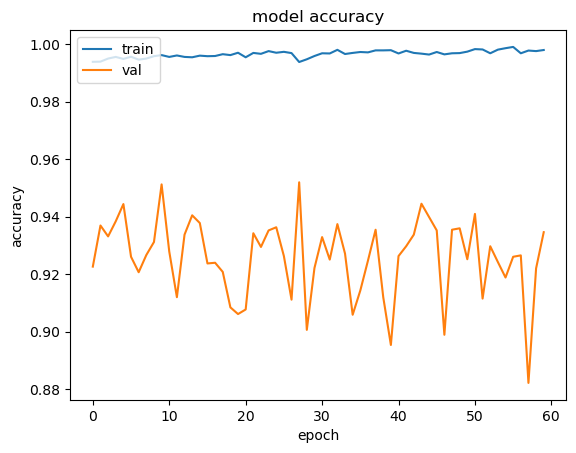

In [78]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

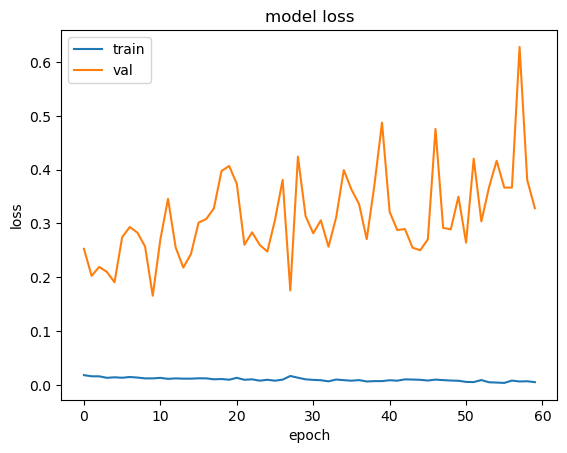

In [79]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [80]:
test_loss, test_accuracy = best_model.evaluate(test_X_list, test_Y)

250/250 ━━━━━━━━━━━━━━━━━━━━ 89s 356ms/step - accuracy: 0.8842 - loss: 0.5247


In [81]:
# Check shapes of test data before evaluation
print("Test X shape:", test_X_list[0].shape)
print("Test Y shape:", test_Y_list[0].shape)

Test X shape: (7987, 80, 6)
Test Y shape: (7987, 5)


In [82]:
#predictions
predictions = best_model.predict(test_X_list)

250/250 ━━━━━━━━━━━━━━━━━━━━ 114s 428ms/step


In [101]:
# Convert predictions to class labels
predicted_classes = tf.argmax(predictions, axis=-1)

# Convert true labels to class labels (if needed)
true_classes = tf.argmax(test_Y, axis=-1)

# Calculate accuracy
accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_classes, true_classes), tf.float32))
print(f"Test accuracy: {accuracy.numpy() * 100:.2f}%")

# Display predicted and true classes for further inspection
print("Predicted classes:", predicted_classes.numpy())
print("True classes:", true_classes.numpy())

Test accuracy: 87.13%
Predicted classes: [4 2 1 ... 0 4 0]
True classes: [4 2 4 ... 4 4 4]


In [102]:
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score

# Convert predictions and true labels to NumPy arrays
# The variables are already numpy arrays, so no conversion is needed.
predicted_classes_np = np.array(predicted_classes)
true_classes_np = np.array(true_classes)

# Generate a classification report (includes precision, recall, F1-score for each class)
report = classification_report(true_classes_np, predicted_classes_np, digits=4)
print("Classification Report:\n", report)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes_np, predicted_classes_np)
print("Confusion Matrix:\n", conf_matrix)

# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
print(f"F1-Scores (per class): {f1_scores}")

# Custom calculation for specificity per class
specificities = []
for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(specificity)

print(f"Specificities (per class): {specificities}")

Classification Report:
               precision    recall  f1-score   support

           0     0.7102    0.9280    0.8047      1487
           1     0.7714    0.9840    0.8648      1063
           2     0.9398    1.0000    0.9689       312
           3     0.9818    0.9983    0.9900       594
           4     0.9670    0.8007    0.8760      4531

    accuracy                         0.8713      7987
   macro avg     0.8740    0.9422    0.9009      7987
weighted avg     0.8932    0.8713    0.8733      7987

Confusion Matrix:
 [[1380    0    0    0  107]
 [   0 1046    0    0   17]
 [   0    0  312    0    0]
 [   0    1    0  593    0]
 [ 563  309   20   11 3628]]
F1-Scores (per class): [0.92804304 0.98400753 1.         0.9983165  0.80070625]
Specificities (per class): [0.9133846153846154, 0.9552281917966493, 0.9973941368078176, 0.99851210604626, 0.9641203703703703]


In [103]:
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score # Import the f1_score function
from sklearn.metrics import precision_recall_fscore_support

# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
print(f"F1-Scores (per class): {f1_scores}")
f1 = f1_score(true_classes_np, predicted_classes_np, average='weighted')
# overall F1 score average
overall_F1 = round(math.fsum(f1_scores) / len(f1_scores),2)
print(f"Overall F1 Score: {overall_F1}")


F1-Scores (per class): [0.92804304 0.98400753 1.         0.9983165  0.80070625]
Overall F1 Score: 0.94


In [104]:
from sklearn.metrics import precision_recall_fscore_support
res = []
for l in [0,1,2,3,4]:
     prec,recall,_,_ = precision_recall_fscore_support(np.array(true_classes_np)==l,
                                                  np.array(predicted_classes_np)==l,
                                                  pos_label=True,average=None)
     res.append([l,recall[0],recall[1]])

sens_spes = pd.DataFrame(res,columns = ['class','specificity','sensitivity'])
print(sens_spes)

overall_specificity = sens_spes['specificity'].mean()
overall_sensitivity = sens_spes['sensitivity'].mean()
print(f"Overall specificity: {round(overall_specificity,2)}")
print(f"Overall sensitivity: {round(overall_sensitivity, 2)}")

   class  specificity  sensitivity
0      0     0.913385     0.928043
1      1     0.955228     0.984008
2      2     0.997394     1.000000
3      3     0.998512     0.998316
4      4     0.964120     0.800706
Overall specificity: 0.97
Overall sensitivity: 0.94


## Confusion Matrix

In [105]:
true_classes = true_classes.numpy()
predicted_classes = predicted_classes.numpy()

In [106]:
print (true_classes)
print (predicted_classes)

[4 2 4 ... 4 4 4]
[4 2 1 ... 0 4 0]


In [107]:
# Compute the confusion matrix
result = confusion_matrix(true_classes, predicted_classes)

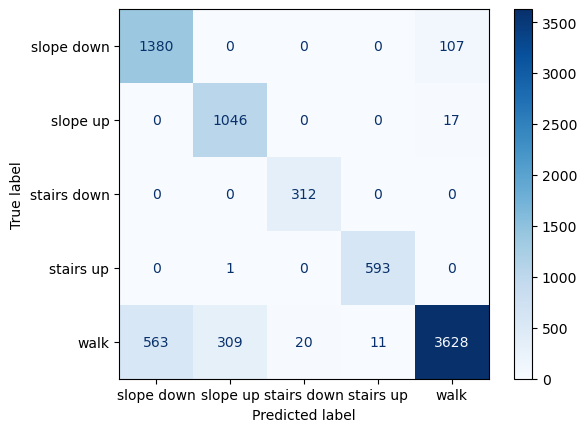

In [108]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'])

cm_display.plot(cmap=plt.cm.Blues)
plt.show()

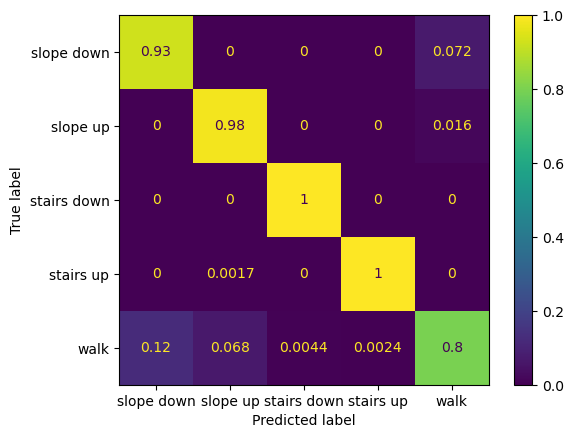

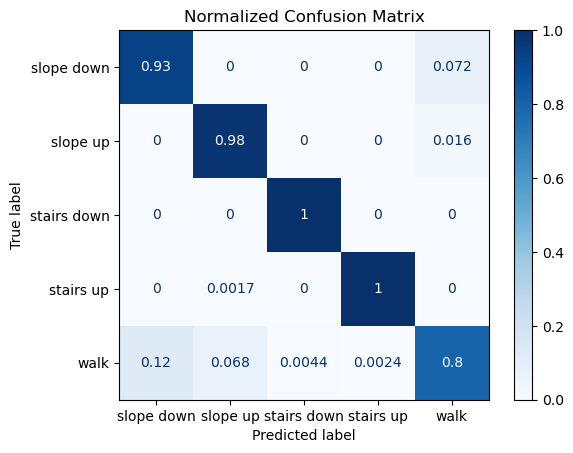

In [109]:
# Create the confusion matrix display using the from_predictions method
cm_display = ConfusionMatrixDisplay.from_predictions(
    true_classes,
    predicted_classes,
    display_labels=['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'],
    normalize='true'  # Normalize by the true labels
)

cm_display.plot(cmap=plt.cm.Blues)

plt.title("Normalized Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
# 0 GR, 1 BNKR, 2 BNKL, 3 SLPD, 4 SLPU, 5 STD, 6 STU, 7 CS, 8 FE

In [ ]:
# 0 GR, 1 SLPD, 2 SLPU, 3 STD, 4 STU, 5 CS, 6 FE